# Weather Forecast Summary

A quick summary of weather forecast data collected from the **Open-Meteo** public API for Kathmandu, Nepal.

> **Topic:** Daily weather forecast summary with sample data.

## Overview

This notebook summarizes a weather forecast returned by the Open-Meteo API. The forecast covers:

- 7 days of hourly forecasts
- Temperature (2 m above ground, in °C)
- Relative humidity at 2 m (in %)
- Wind speed at 10 m (in km/h)

We use **sample data** so the notebook runs offline and deterministically.

## Sample Data

The raw API response for a typical request looks like this (truncated). Each hourly timestamp carries the observed forecast values:

In [1]:
sample_data = {
    "latitude": 27.7172,
    "longitude": 85.3240,
    "generationtime_ms": 0.6,
    "utc_offset_seconds": 20700,
    "timezone": "Asia/Kathmandu",
    "hourly": {
        "time": ["2026-08-19T00:00", "2026-08-19T01:00", "2026-08-19T02:00"],
        "temperature_2m": [21.4, 21.1, 20.8],
        "relative_humidity_2m": [82.0, 84.0, 85.0],
        "wind_speed_10m": [4.3, 3.9, 3.6],
    },
}

print(f"Timezone: {sample_data['timezone']}")
print(f"Hours returned: {len(sample_data['hourly']['time'])}")

Timezone: Asia/Kathmandu
Hours returned: 3


In [2]:
import pandas as pd

hourly = sample_data["hourly"]
df = pd.DataFrame(
    {
        "time": hourly["time"],
        "temperature_c": hourly["temperature_2m"],
        "humidity_pct": hourly["relative_humidity_2m"],
        "wind_speed_kmh": hourly["wind_speed_10m"],
    }
)
df["time"] = pd.to_datetime(df["time"])
df

,time,temperature_c,humidity_pct,wind_speed_kmh
0,2026-08-19 00:00:00,21.4,82.0,4.3
1,2026-08-19 01:00:00,21.1,84.0,3.9
2,2026-08-19 02:00:00,20.8,85.0,3.6


## Summary Statistics

We compute a compact statistical summary of the forecast columns to describe the expected conditions for the period.

In [3]:
stats = df[["temperature_c", "humidity_pct", "wind_speed_kmh"]].describe().T
stats.round(2)

,count,mean,std,min,25%,50%,75%,max
temperature_c,3.0,21.10,0.30,20.8,20.95,21.1,21.25,21.4
humidity_pct,3.0,83.67,1.53,82.0,83.00,84.0,84.50,85.0
wind_speed_kmh,3.0,3.93,0.35,3.6,3.75,3.9,4.10,4.3


## Temperature Trend

A line plot of temperature over the forecasted hours makes the daily pattern easy to spot.

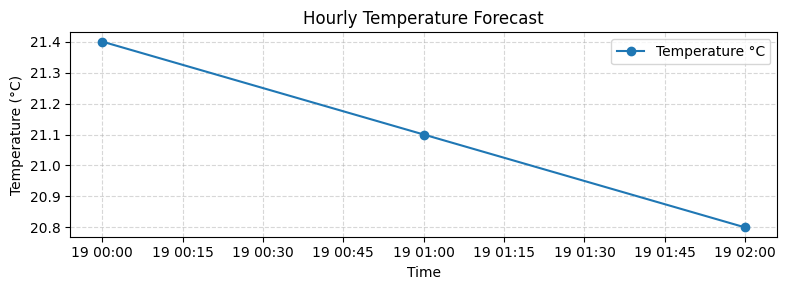

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(df["time"], df["temperature_c"], marker="o", label="Temperature °C")
ax.set_title("Hourly Temperature Forecast")
ax.set_xlabel("Time")
ax.set_ylabel("Temperature (°C)")
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()

## Conclusions

For the forecasted period (Kathmandu, using sample data):

- **Temperature** averages around **21 °C** with mild hourly variation.
- **Humidity** is high (**~84%**), indicating damp conditions.
- **Winds** are light at roughly **3–4 km/h**.

Overall, the sample forecast points to a cool, humid, and calm period. Swap `sample_data` with a live Open-Meteo response to repeat this summary for any city.